Shape: (506, 14)

Data Types:
 CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Missing Values:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Descriptive Statistics:
              CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    

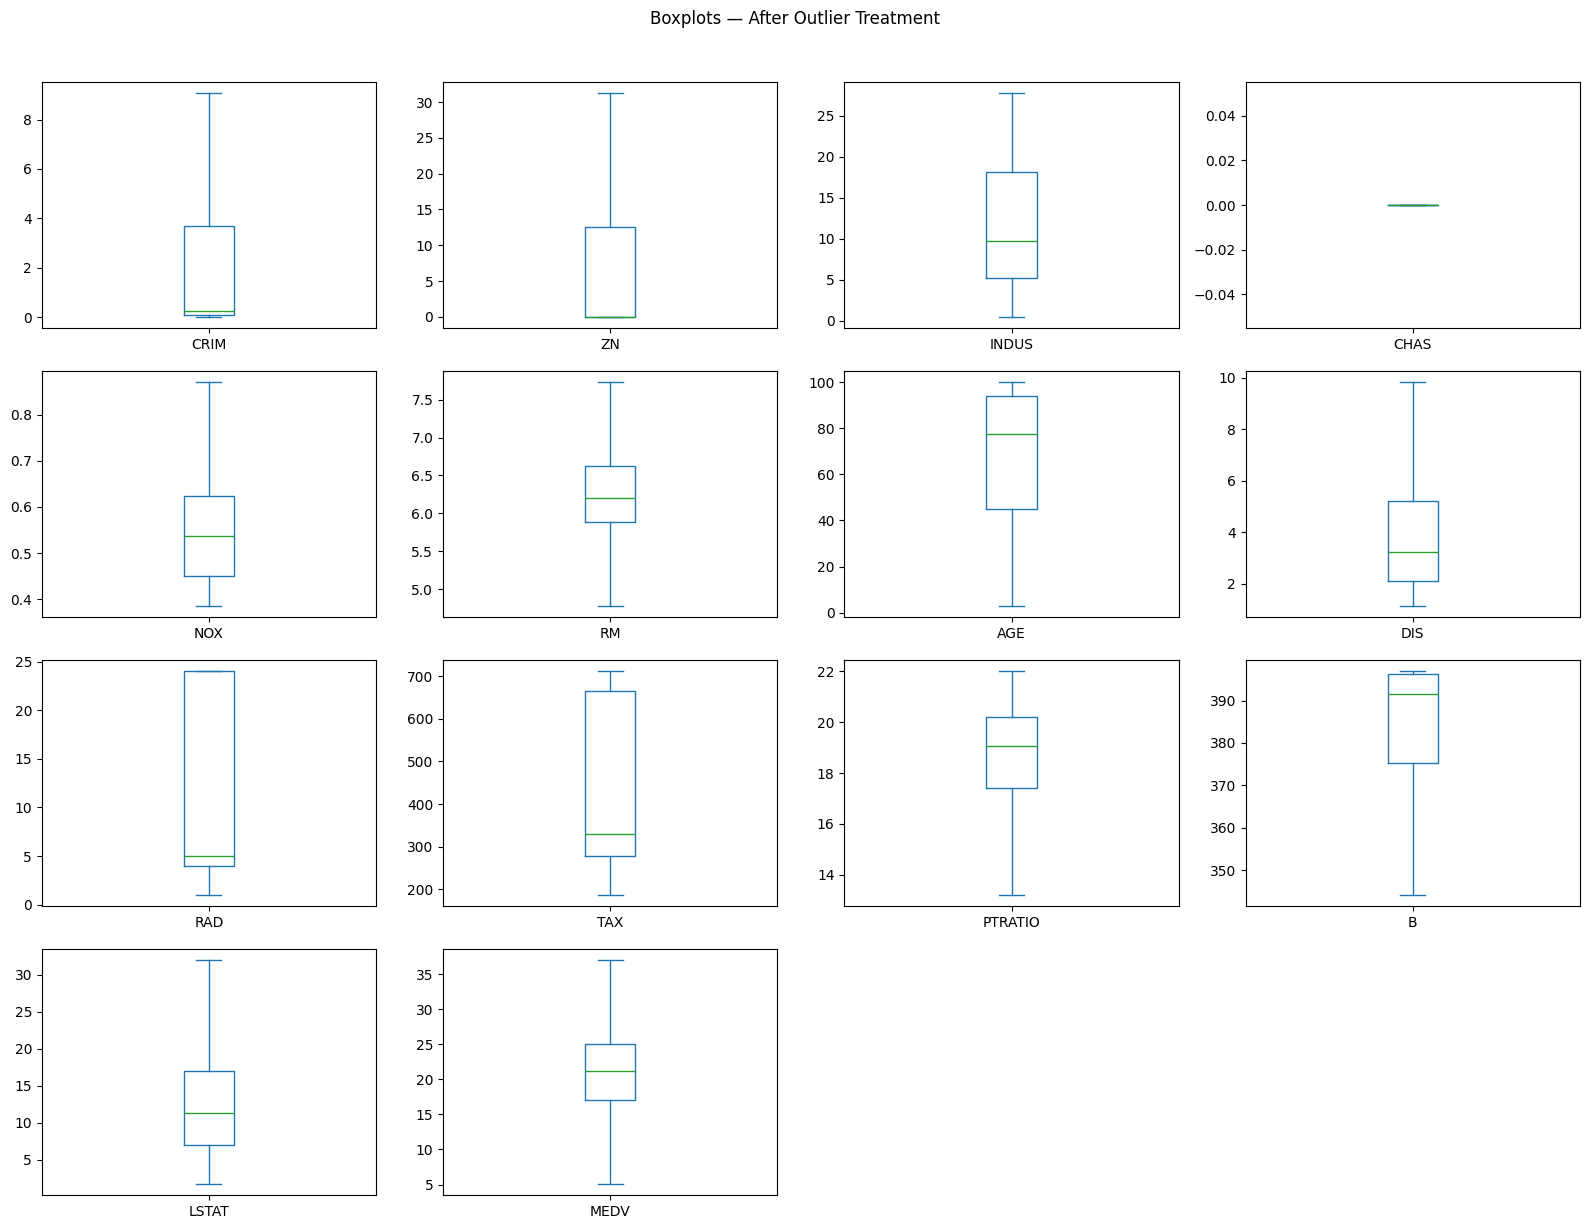

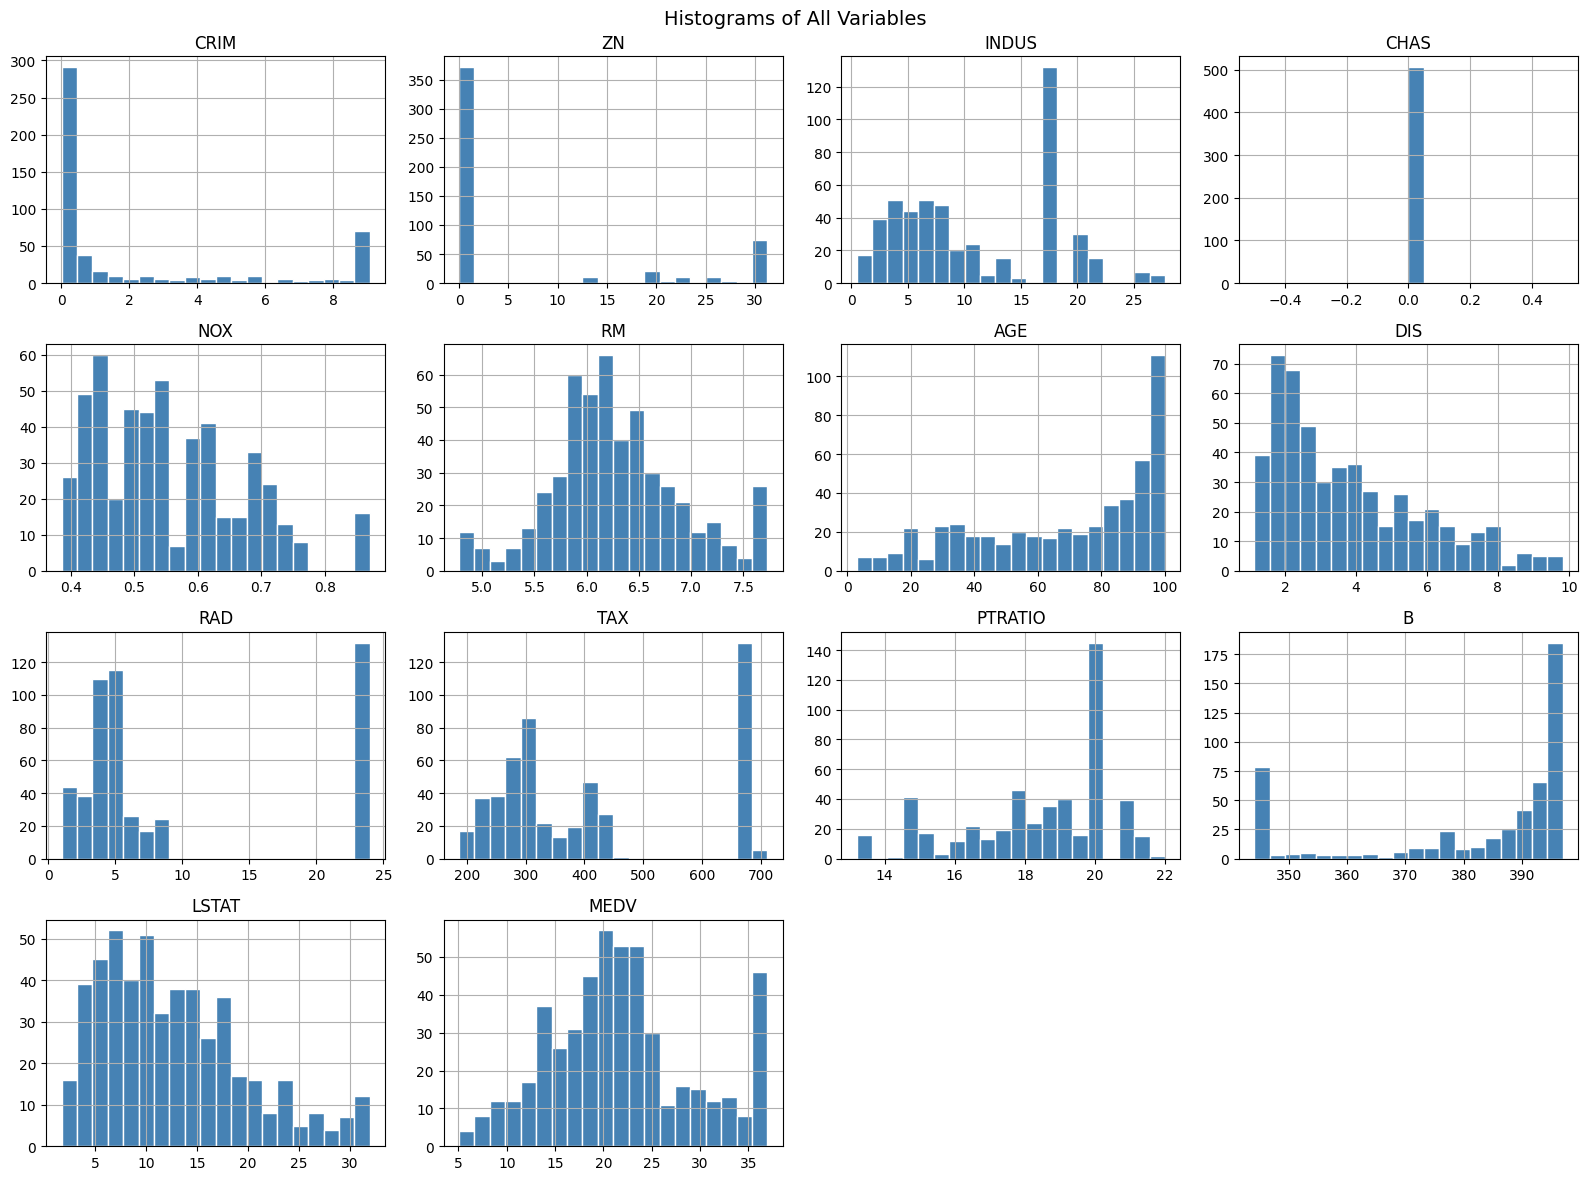

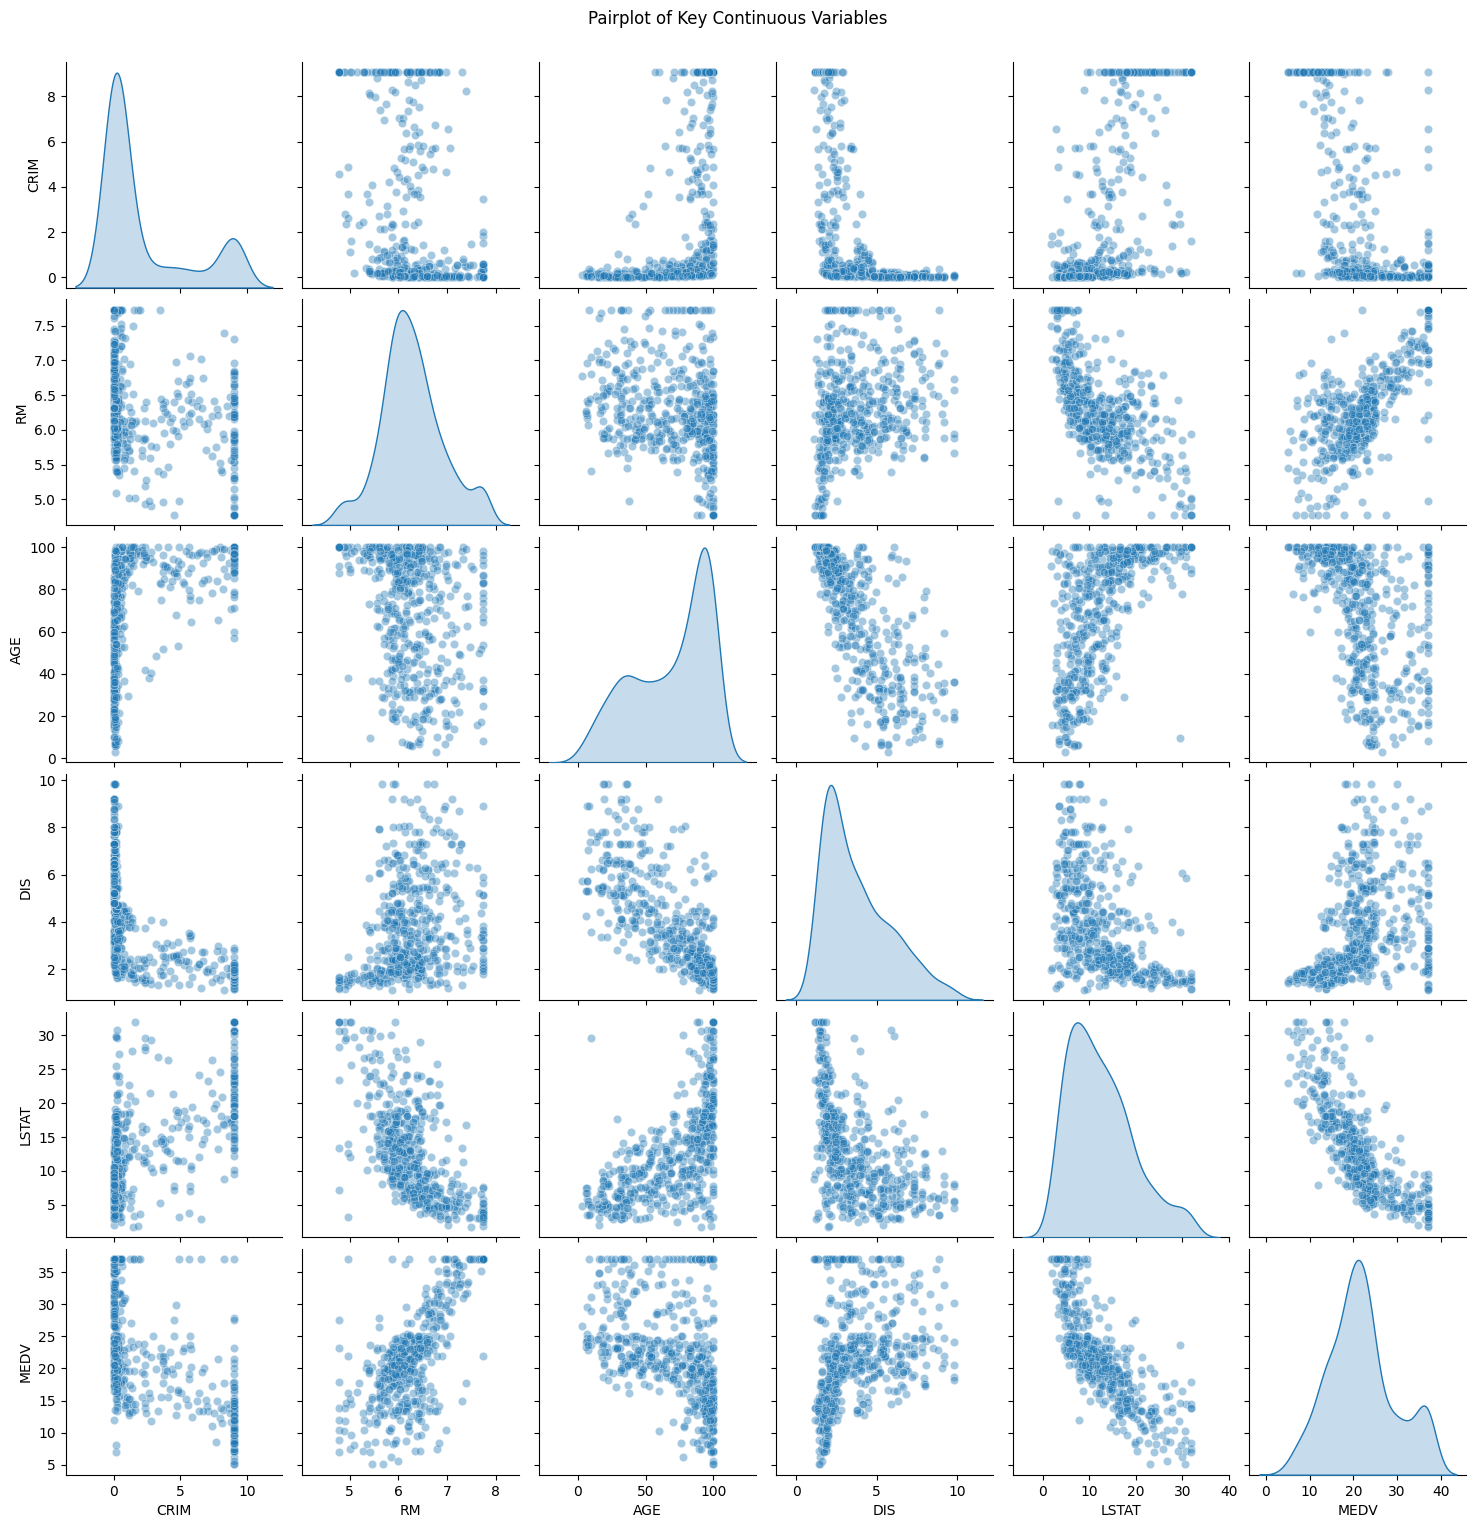

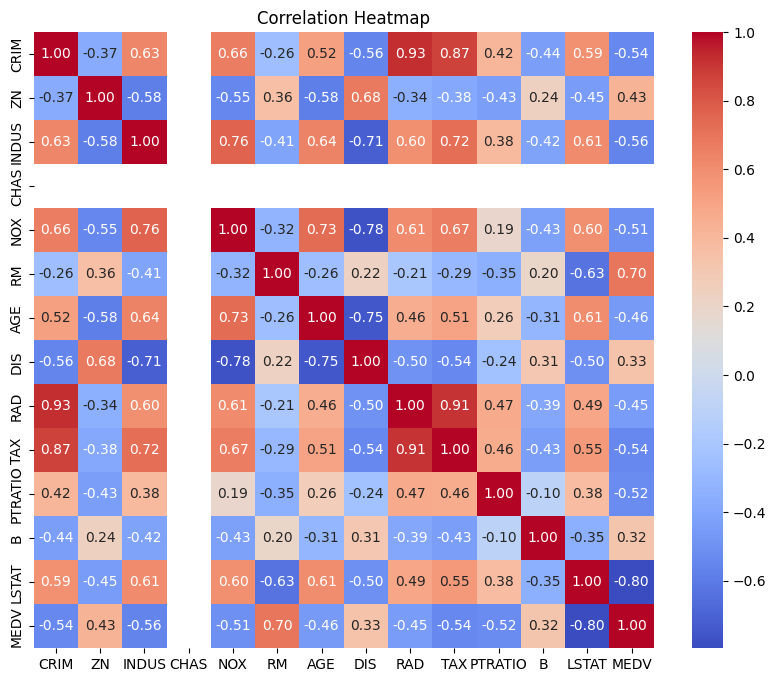

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset_Day5.csv")

# Basic Info 
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

# Missing Values 
print("\nMissing Values:\n", df.isnull().sum())
# No missing values found — no treatment needed

# Descriptive Statistics 
print("\nDescriptive Statistics:\n", df.describe())

# Outlier Detection using IQR 
print("\nOutlier Count per Column (IQR method):")
for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {outliers}")

# Outlier Treatment (cap using IQR bounds) 
df_clean = df.copy()
for col in df_clean.columns:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

# Boxplots for all variables 
df_clean.plot(kind='box', subplots=True, layout=(4, 4),
              figsize=(16, 12), title='Boxplots of All Variables')
plt.suptitle("Boxplots — After Outlier Treatment", y=1.02)
plt.tight_layout()
plt.show()

#  Histograms for continuous variables
df_clean.hist(figsize=(16, 12), bins=20, color='steelblue', edgecolor='white')
plt.suptitle("Histograms of All Variables", fontsize=14)
plt.tight_layout()
plt.show()

# Pairplot for continuous variables 
continuous_cols = ['CRIM', 'RM', 'AGE', 'DIS', 'LSTAT', 'MEDV']
sns.pairplot(df_clean[continuous_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle("Pairplot of Key Continuous Variables", y=1.02)
plt.show()

#  Correlation Heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 Model: MEDV ~ RM 
Equation  : MEDV = 8.8800 * RM + (-33.1070)
R² Score  : 0.4885
RMSE      : 7.0290
MAE       : 4.5981

Predicted MEDV for RM = 7 : $29.0533k


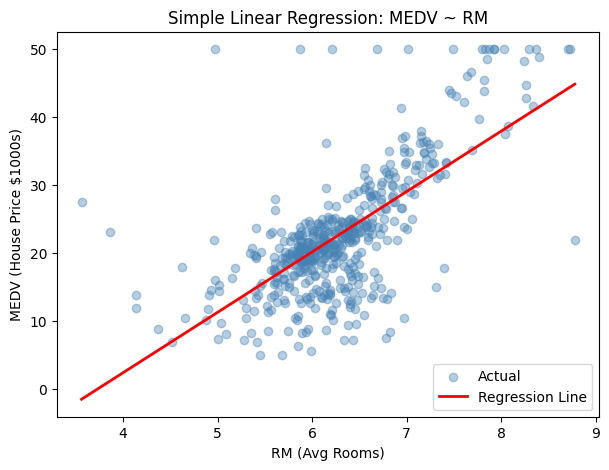

In [7]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_rm = df[['RM']].values
y    = df['MEDV'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_rm, y, test_size=0.2, random_state=100)

# ── Train model ─────────────────────────────────────────────────────────
model_rm = LinearRegression()
model_rm.fit(X_train, y_train)

# ── Evaluate ────────────────────────────────────────────────────────────
y_pred = model_rm.predict(X_test)

print(" Model: MEDV ~ RM ")
print(f"Equation  : MEDV = {model_rm.coef_[0]:.4f} * RM + ({model_rm.intercept_:.4f})")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")

# ── Predict for RM = 7 ──────────────────────────────────────────────────
pred_rm7 = model_rm.predict([[7]])[0]
print(f"\nPredicted MEDV for RM = 7 : ${pred_rm7:.4f}k")

# ── Plot regression line ─────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(df['RM'], df['MEDV'], alpha=0.4, color='steelblue', label='Actual')
x_line = np.linspace(df['RM'].min(), df['RM'].max(), 100)
plt.plot(x_line, model_rm.coef_[0]*x_line + model_rm.intercept_,
         color='red', linewidth=2, label='Regression Line')
plt.xlabel("RM (Avg Rooms)")
plt.ylabel("MEDV (House Price $1000s)")
plt.title("Simple Linear Regression: MEDV ~ RM")
plt.legend()
plt.show()

 Model: MEDV ~ DIS 
Equation  : MEDV = 1.1185 * DIS + (18.3828)
R² Score  : 0.0541
RMSE      : 9.5587
MAE       : 6.7776

Predicted MEDV for DIS = 15 : $35.1599k


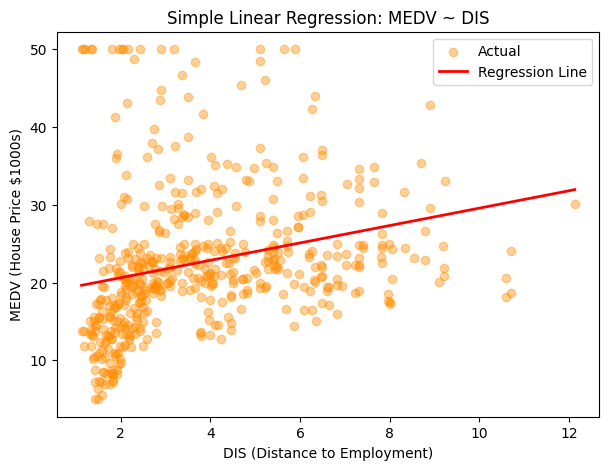

In [8]:

X_dis = df[['DIS']].values

X_train, X_test, y_train, y_test = train_test_split(
    X_dis, y, test_size=0.2, random_state=100)

# ── Train model ─────────────────────────────────────────────────────────
model_dis = LinearRegression()
model_dis.fit(X_train, y_train)

# ── Evaluate ────────────────────────────────────────────────────────────
y_pred = model_dis.predict(X_test)

print(" Model: MEDV ~ DIS ")
print(f"Equation  : MEDV = {model_dis.coef_[0]:.4f} * DIS + ({model_dis.intercept_:.4f})")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")

# ── Predict for DIS = 15 ────────────────────────────────────────────────
pred_dis15 = model_dis.predict([[15]])[0]
print(f"\nPredicted MEDV for DIS = 15 : ${pred_dis15:.4f}k")

# ── Plot regression line ─────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(df['DIS'], df['MEDV'], alpha=0.4, color='darkorange', label='Actual')
x_line = np.linspace(df['DIS'].min(), df['DIS'].max(), 100)
plt.plot(x_line, model_dis.coef_[0]*x_line + model_dis.intercept_,
         color='red', linewidth=2, label='Regression Line')
plt.xlabel("DIS (Distance to Employment)")
plt.ylabel("MEDV (House Price $1000s)")
plt.title("Simple Linear Regression: MEDV ~ DIS")
plt.legend()
plt.show()